In [15]:
"""
Convertible Bond Arbitrage — Backtest Engine
=============================================
Strategy: Long convertible bond + Short underlying stock (delta hedge)
Universe: Recommended bonds from fair_price (backtest_recommended_tickers.csv) or all with data
Period:   2023-01-01 to 2026-02-27 (configurable; favorable rate environment)
Capital:  $10,000,000 starting NAV
Sizing:   $1,000,000 per position; cash reserve 0.1%

Entry:    When bond-specific mispricing threshold is crossed
Exit:     Convergence / Stop loss / Maturity / No data
Hedge:    Delta rebalanced daily when drift exceeds bond-specific threshold
Cash:     Uninvested capital earns risk-free rate (from yield curve)

Outputs:
    data/clean/backtest/
        trades.csv          — every entry, exit, rebalance event
        pnl_daily.csv       — daily P&L by component by position
        portfolio_nav.csv   — daily portfolio NAV and returns
        performance.csv     — final summary metrics
"""

import pandas as pd
import numpy as np
import os
import getpass
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
USER = getpass.getuser()
if USER == "sarda":
    BASE_DIR = r"C:\Users\sarda\Desktop\cba2"
elif USER == "jinay":
    BASE_DIR = r"C:\Users\jinay\Desktop\cba2"
else:
    BASE_DIR = r"C:\Users\sarda\Desktop\cba2"

FV_DIR       = os.path.join(BASE_DIR, "data", "clean", "fair_value")
DISCOUNT_PATH= os.path.join(BASE_DIR, "data", "clean", "final_discount_rates_daily.csv")
OUTPUT_DIR   = os.path.join(BASE_DIR, "data", "clean", "backtest")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════
# SECTION 1 — CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════

STARTING_CAPITAL   = 10_000_000
POSITION_SIZE      = 1_000_000     # per bond
CASH_RESERVE_PCT   = 0.001         # min cash to keep (0.1%); reserve earns T-bill, reduces deployment
PAR                = 1000          # face value per bond

# Bond-specific parameters — calibrated to signal distributions
BOND_CONFIG = {
    "MTH": {
        "entry_threshold"  : 2.0,   # mispricing_pct > 2.0% to enter
        "exit_threshold"   : 0.5,   # mispricing_pct < 0.5% to exit (convergence)
        "stop_loss_pct"    : -6.0,  # exit if position P&L < -6% of initial value
        "rebal_trigger"    : 0.05,  # rebalance if |delta_new - delta_current| > 0.05
        "borrow_rate"      : 0.0075,# annual borrow cost on short stock position
        "no_entry_after"   : None,  # no date restriction
        "force_exit_by"    : None,
    },
    "DUK": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -8.0,
        "rebal_trigger"    : 0.07,
        "borrow_rate"      : 0.0025,
        "no_entry_after"   : pd.Timestamp("2025-10-01"),  # matures Apr 2026
        "force_exit_by"    : pd.Timestamp("2026-01-15"),
    },
    "NEE": {
        "entry_threshold"  : 3.5,
        "exit_threshold"   : 1.5,
        "stop_loss_pct"    : -10.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.0025,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "DLR": {
        "entry_threshold"  : 2.5,
        "exit_threshold"   : 0.75,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.08,
        "borrow_rate"      : 0.0040,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    # ── Expanded universe (calibrated to signal/mispricing like MTH, DUK, NEE, DLR) ─
    "KRG": {
        "entry_threshold"  : 4.0,   # high avg misp ~14%, signal ~95%
        "exit_threshold"   : 1.5,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "PPL1": {
        "entry_threshold"  : 3.5,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "EXC": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "BXP": {
        "entry_threshold"  : 4.0,   # avg misp ~9%, high signal
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "EEFT": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "WEC1": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "WEC2": {
        "entry_threshold"  : 4.0,   # avg misp ~10%, 100% signal
        "exit_threshold"   : 1.5,
        "stop_loss_pct"    : -8.0,
        "rebal_trigger"    : 0.06,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "WEC3": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "REXR1": {
        "entry_threshold"  : 2.5,   # selective signal ~35%, lower entry to get trades
        "exit_threshold"   : 0.75,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "REXR2": {
        "entry_threshold"  : 3.5,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "FRT": {
        "entry_threshold"  : 3.5,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "EVRG": {
        "entry_threshold"  : 3.5,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -8.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "CDP": {
        "entry_threshold"  : 5.0,   # very high avg misp ~16%, require strong signal
        "exit_threshold"   : 1.5,
        "stop_loss_pct"    : -8.0,
        "rebal_trigger"    : 0.06,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "VTR": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
    "PPL2": {
        "entry_threshold"  : 3.0,
        "exit_threshold"   : 1.0,
        "stop_loss_pct"    : -7.0,
        "rebal_trigger"    : 0.05,
        "borrow_rate"      : 0.003,
        "no_entry_after"   : None,
        "force_exit_by"    : None,
    },
}

TICKERS = list(BOND_CONFIG.keys())     # full universe; load_data() uses only bonds with fair_value files

# Transaction costs
# Bond TC: 100 bps one-way (2.0% round-trip) — conservative but realistic
BOND_TC_BPS  = 50   # basis points on bond notional (entry and exit)
STOCK_TC_BPS = 5     # basis points on stock notional (all stock trades)

# Maturity buffer — exit when remaining maturity drops below this
MATURITY_EXIT_YEARS = 0.25   # 3 months

# Minimum consecutive data days before triggering "no data" exit
NO_DATA_EXIT_DAYS = 3

# Max holding period — force exit after this many calendar days (avoids multi-year single positions)
MAX_HOLD_DAYS = 365

# Rebalance also if stock moves more than this in one day
LARGE_MOVE_TRIGGER = 0.10    # 10%

# Backtest period — restrict to dates when yield curve was favorable
BACKTEST_START = pd.Timestamp("2023-01-01")
BACKTEST_END   = pd.Timestamp("2026-02-27")

# Optional: use only bonds recommended by fair_price (better portfolio)
RECOMMENDED_TICKERS_PATH = os.path.join(BASE_DIR, "data", "clean", "backtest_recommended_tickers.csv")


# ══════════════════════════════════════════════════════════════════════════
# SECTION 2 — DATA LOADING
# ══════════════════════════════════════════════════════════════════════════

def load_data(use_recommended_only=True):
    """
    Load fair value files. If use_recommended_only and backtest_recommended_tickers.csv
    exists (from fair_price_calculation), load only those bonds for a better portfolio.
    Returns a dict {ticker: DataFrame} and the discount DataFrame.
    """
    tickers_to_load = TICKERS
    if use_recommended_only and os.path.exists(RECOMMENDED_TICKERS_PATH):
        rec_df = pd.read_csv(RECOMMENDED_TICKERS_PATH)
        rec_tickers = set(rec_df["ticker"].astype(str).str.strip().tolist())
        tickers_to_load = [t for t in TICKERS if t in rec_tickers]
        print(f"  Using recommended universe: {len(tickers_to_load)} bonds from backtest_recommended_tickers.csv")
    bond_data = {}
    for ticker in tickers_to_load:
        path = os.path.join(FV_DIR, f"{ticker}_fair_value.csv")
        if not os.path.exists(path):
            print(f"  SKIP {ticker}: fair value file not found")
            continue
        df = pd.read_csv(path, parse_dates=["date"])
        df = df.sort_values("date").reset_index(drop=True)
        bond_data[ticker] = df
        print(f"  Loaded {ticker}: {len(df)} rows | "
              f"{df['date'].min().date()} to {df['date'].max().date()}")

    if not bond_data:
        raise FileNotFoundError("No fair value files found. Run fair_price_calculation first.")

    discount_df = pd.read_csv(DISCOUNT_PATH, parse_dates=["Date"])
    discount_df = discount_df.sort_values("Date").reset_index(drop=True)

    return bond_data, discount_df


def get_risk_free_rate_on_date(discount_df, date):
    """Get the 1-year risk-free rate for a given date (for cash return)."""
    row = discount_df[discount_df["Date"] == date]
    if row.empty:
        idx = (discount_df["Date"] - date).abs().idxmin()
        row = discount_df.iloc[[idx]]
    return float(row["risk_free_1y"].values[0])


def build_master_calendar(bond_data):
    """
    Build a sorted list of all unique trading dates across all bonds.
    The backtest runs on this calendar.
    """
    all_dates = set()
    for df in bond_data.values():
        all_dates.update(df["date"].tolist())
    return sorted(all_dates)


def get_bond_row(bond_data, ticker, date):
    """
    Get the data row for a ticker on a specific date.
    Returns None if no data exists for that date.
    """
    df  = bond_data[ticker]
    row = df[df["date"] == date]
    if row.empty:
        return None
    return row.iloc[0]


# ══════════════════════════════════════════════════════════════════════════
# SECTION 3 — POSITION CLASS
# ══════════════════════════════════════════════════════════════════════════

class Position:
    """
    Represents one open convertible arb position.

    Long N_bonds bonds + Short shares_short shares of the underlying stock.
    Tracks all P&L components separately from entry to exit.
    """

    def __init__(self, ticker, entry_date, entry_row, position_id):
        cfg = BOND_CONFIG[ticker]

        self.ticker          = ticker
        self.position_id     = position_id
        self.entry_date      = entry_date
        self.status          = "open"
        self.exit_date       = None
        self.exit_reason     = None

        # Entry prices
        self.entry_dirty     = float(entry_row["market_dirty_price"])
        self.entry_clean     = float(entry_row["market_clean_price"])
        self.entry_stock     = float(entry_row["stock_price"])
        self.entry_delta     = float(entry_row["delta"])
        self.entry_mispricing= float(entry_row["mispricing_pct"])
        self.conversion_ratio= float(entry_row["conversion_price"]) # not ratio — fix below
        # Use conversion_price from fair value file to derive ratio
        # conversion_ratio = option_value_per_bond / option_value (per share)
        # We stored it indirectly — compute from option_value_pct and option_value
        opt_val      = float(entry_row["option_value"])         # per share
        opt_per_bond = float(entry_row["option_value_per_bond"])# per bond
        self.conversion_ratio = (opt_per_bond / opt_val
                                 if opt_val > 0 else 0)

        # Position sizing — invest exactly POSITION_SIZE in dirty price
        self.initial_investment = POSITION_SIZE
        self.N_bonds      = POSITION_SIZE / (self.entry_dirty / 100 * PAR)
        self.current_delta= self.entry_delta
        self.shares_short = self.current_delta * self.conversion_ratio * self.N_bonds

        # Running P&L components (cumulative)
        self.pnl_coupon   = 0.0
        self.pnl_bond_mtm = 0.0
        self.pnl_short    = 0.0
        self.pnl_gamma    = 0.0
        self.costs_borrow = 0.0
        self.rebate_income= 0.0
        self.costs_tc     = 0.0

        # Transaction costs on entry
        bond_notional_entry  = self.N_bonds * (self.entry_dirty / 100 * PAR)
        stock_notional_entry = self.shares_short * self.entry_stock
        tc_entry = (bond_notional_entry  * BOND_TC_BPS  / 10000 +
                    stock_notional_entry * STOCK_TC_BPS / 10000)
        self.costs_tc += tc_entry

        # Previous day prices (for daily P&L)
        self.prev_dirty  = self.entry_dirty
        self.prev_stock  = self.entry_stock
        self.prev_delta  = self.entry_delta

        # Consecutive missing data counter
        self.missing_days = 0

    @property
    def total_pnl(self):
        return (self.pnl_coupon + self.pnl_bond_mtm + self.pnl_short
                + self.pnl_gamma - self.costs_borrow + self.rebate_income - self.costs_tc)

    @property
    def pnl_pct(self):
        return self.total_pnl / self.initial_investment * 100

    @property
    def current_value(self):
        return self.initial_investment + self.total_pnl


# ══════════════════════════════════════════════════════════════════════════
# SECTION 4 — DAILY UPDATE LOGIC
# ══════════════════════════════════════════════════════════════════════════

def update_position(position, today_row, date, discount_df):
    """
    Update one open position for a single trading day.
    Computes daily P&L by component, applies borrow cost,
    and checks for delta rebalancing.
    Returns dict of today's daily P&L components.
    """
    ticker    = position.ticker
    cfg       = BOND_CONFIG[ticker]
    cpn_rate  = float(today_row.get("effective_discount_rate", 0)) * 0   # placeholder
    # Actual coupon rate: we infer from option_value and bond data
    # We stored accrued_interest in the fair value file — use that to back out coupon
    # daily coupon accrual = accrued interest change day over day (approx)
    # Better: use the coupon rate from fair value effective_discount_rate
    # Actually the cleanest way: coupon P&L = accrued_interest_today - accrued_interest_yesterday
    # We track accrued interest in the fair value file

    today_dirty  = float(today_row["market_dirty_price"])
    today_clean  = float(today_row["market_clean_price"])
    today_stock  = float(today_row["stock_price"])
    today_delta  = float(today_row["delta"])
    today_accr   = float(today_row["accrued_interest"])
    today_misp   = float(today_row["mispricing_pct"])
    today_maturity = float(today_row["remaining_maturity"])

    # ── 1. Coupon P&L ─────────────────────────────────────────────────────
    # Accrued interest increases daily and resets at each coupon payment.
    # The jump on coupon payment date is the actual cash received.
    # daily_coupon = change in accrued interest (positive most days,
    # large negative on coupon date = cash received that day)
    # We approximate as: daily coupon income = coupon_rate * par * N_bonds / 252
    # Using accrued interest delta is cleaner but requires yesterday's accrued
    # We use the position's stored prev values
    prev_accr = getattr(position, 'prev_accrued', today_accr)
    accr_change = today_accr - prev_accr

    # If accrued dropped (coupon payment occurred), the actual coupon was received
    # Accrued interest is in % of par
    if accr_change < -0.1:
        # Coupon payment day: income = full coupon payment + accrued change
        # The drop in accrued = coupon paid out → that is income
        daily_coupon = abs(accr_change) / 100 * PAR * position.N_bonds
    else:
        # Normal day: income is the daily accrual
        daily_coupon = max(accr_change, 0) / 100 * PAR * position.N_bonds

    # ── 2. Bond MTM P&L ───────────────────────────────────────────────────
    # Change in dirty price captures both price movement AND accrual
    bond_price_change = (today_dirty - position.prev_dirty) / 100 * PAR
    daily_bond_mtm    = bond_price_change * position.N_bonds

    # ── 3. Short leg P&L ──────────────────────────────────────────────────
    stock_change   = today_stock - position.prev_stock
    daily_short    = -stock_change * position.shares_short

    # ── 4. Gamma P&L ──────────────────────────────────────────────────────
    # Gamma P&L = actual bond move - delta-predicted bond move
    # delta-predicted bond move = delta * stock_change * conversion_ratio
    delta_pred_bond = (position.prev_delta * stock_change
                       * position.conversion_ratio
                       * position.N_bonds)
    daily_gamma = daily_bond_mtm - delta_pred_bond

    # ── 5. Borrow cost ────────────────────────────────────────────────────
    borrow_notional = position.shares_short * today_stock
    daily_borrow    = borrow_notional * cfg["borrow_rate"] / 252

    # Short rebate: cash from the short earns risk-free minus borrow
    rf_rate       = get_risk_free_rate_on_date(discount_df, date)
    rebate_annual = max(rf_rate - cfg["borrow_rate"], 0)
    daily_rebate  = borrow_notional * rebate_annual / 252

    # ── Accumulate ────────────────────────────────────────────────────────
    position.pnl_coupon   += daily_coupon
    position.pnl_bond_mtm += daily_bond_mtm
    position.pnl_short    += daily_short
    position.pnl_gamma    += daily_gamma
    position.costs_borrow += daily_borrow
    position.rebate_income+= daily_rebate

    # ── 6. Delta rebalancing ──────────────────────────────────────────────
    delta_drift  = abs(today_delta - position.current_delta)
    stock_move   = abs(stock_change / position.prev_stock) if position.prev_stock > 0 else 0
    rebal_cost   = 0.0
    shares_traded= 0.0

    if delta_drift > cfg["rebal_trigger"] or stock_move > LARGE_MOVE_TRIGGER:
        new_shares      = today_delta * position.conversion_ratio * position.N_bonds
        shares_traded   = abs(new_shares - position.shares_short)
        rebal_notional  = shares_traded * today_stock
        rebal_cost      = rebal_notional * STOCK_TC_BPS / 10000
        position.costs_tc       += rebal_cost
        position.shares_short    = new_shares
        position.current_delta   = today_delta

    # ── Update previous day values ─────────────────────────────────────────
    position.prev_dirty    = today_dirty
    position.prev_stock    = today_stock
    position.prev_delta    = today_delta
    position.prev_accrued  = today_accr

    return {
        "daily_coupon"    : daily_coupon,
        "daily_bond_mtm"  : daily_bond_mtm,
        "daily_short"     : daily_short,
        "daily_gamma"     : daily_gamma,
        "daily_borrow"    : -daily_borrow,
        "daily_rebate"    : daily_rebate,
        "daily_rebal_cost": -rebal_cost,
        "daily_total"     : (daily_coupon + daily_bond_mtm + daily_short
                             + daily_gamma - daily_borrow + daily_rebate - rebal_cost),
        "today_mispricing": today_misp,
        "today_delta"     : today_delta,
        "shares_traded"   : shares_traded,
        "rebalanced"      : delta_drift > cfg["rebal_trigger"] or stock_move > LARGE_MOVE_TRIGGER,
    }


# ══════════════════════════════════════════════════════════════════════════
# SECTION 5 — EXIT CHECKING
# ══════════════════════════════════════════════════════════════════════════

def check_exit(position, today_row, date):
    """
    Check all exit conditions for an open position.
    Returns exit_reason string if should exit, else None.

    Exit priority order:
        1. Force exit by date (DUK maturity approaching)
        2. Maturity buffer (remaining maturity < 3 months)
        3. Max hold (365 days)
        4. Stop loss
        5. Convergence (mispricing closed)
        6. No data (handled in main loop)
    """
    ticker = position.ticker
    cfg    = BOND_CONFIG[ticker]

    # 1. Force exit date
    if cfg["force_exit_by"] is not None and date >= cfg["force_exit_by"]:
        return "force_exit_maturity"

    # 2. Remaining maturity
    if float(today_row["remaining_maturity"]) < MATURITY_EXIT_YEARS:
        return "maturity_buffer"

    # 3. Max holding period
    if (date - position.entry_date).days >= MAX_HOLD_DAYS:
        return "max_hold"

    # 4. Stop loss
    if position.pnl_pct < cfg["stop_loss_pct"]:
        return "stop_loss"

    # 5. Convergence — mispricing has closed
    if float(today_row["mispricing_pct"]) < cfg["exit_threshold"]:
        return "convergence"

    return None


def close_position(position, today_row, date, exit_reason):
    """
    Close a position: apply exit transaction costs and record.
    """
    position.status      = "closed"
    position.exit_date   = date
    position.exit_reason = exit_reason

    today_dirty  = float(today_row["market_dirty_price"])
    today_stock  = float(today_row["stock_price"])

    # Exit transaction costs
    bond_notional_exit  = position.N_bonds * (today_dirty / 100 * PAR)
    stock_notional_exit = position.shares_short * today_stock
    tc_exit = (bond_notional_exit  * BOND_TC_BPS  / 10000 +
               stock_notional_exit * STOCK_TC_BPS / 10000)
    position.costs_tc += tc_exit

    return {
        "exit_dirty" : today_dirty,
        "exit_stock" : today_stock,
        "exit_mispricing": float(today_row["mispricing_pct"]),
        "tc_exit"    : tc_exit,
    }


# ══════════════════════════════════════════════════════════════════════════
# SECTION 6 — MAIN BACKTEST LOOP
# ══════════════════════════════════════════════════════════════════════════

def run_backtest(bond_data, discount_df):
    """
    Main backtest loop. Iterates over every trading date,
    manages positions, tracks NAV.
    """
    calendar      = build_master_calendar(bond_data)
    calendar      = [d for d in calendar if BACKTEST_START <= pd.Timestamp(d) <= BACKTEST_END]
    if not calendar:
        raise ValueError(f"No trading days in backtest period {BACKTEST_START.date()} to {BACKTEST_END.date()}")
    cash          = STARTING_CAPITAL
    open_positions= {}   # ticker → Position (one position per bond at most)
    all_positions = []   # list of all Position objects (open + closed)
    trade_log     = []   # every entry/exit/rebalance event
    pnl_daily_log = []   # daily P&L per position
    nav_log       = []   # daily portfolio NAV

    position_counter = 0

    available_tickers = sorted(bond_data.keys())
    print(f"\nBacktest period: {BACKTEST_START.date()} to {BACKTEST_END.date()}")
    print(f"Backtest running over {len(calendar)} trading days...")
    print(f"  Start: {calendar[0].date()}  |  End: {calendar[-1].date()}")
    print(f"  Bonds: {available_tickers}")
    print(f"  Starting capital: ${STARTING_CAPITAL:,.0f}\n")

    for date in calendar:
        daily_pnl_total  = 0.0
        daily_cash_income= 0.0

        # ── Cash earns risk-free rate ──────────────────────────────────────
        rf_rate          = get_risk_free_rate_on_date(discount_df, date)
        daily_cash_income= cash * rf_rate / 252
        cash            += daily_cash_income

        # ══ STEP 1: UPDATE + CHECK EXITS for open positions ═══════════════
        positions_to_close = []

        for ticker, pos in list(open_positions.items()):
            row = get_bond_row(bond_data, ticker, date)

            # Handle missing data
            if row is None:
                pos.missing_days += 1
                if pos.missing_days >= NO_DATA_EXIT_DAYS:
                    # Use last known prices — approximate exit
                    positions_to_close.append((ticker, pos, None, "no_data"))
                continue
            else:
                pos.missing_days = 0

            # Update P&L
            daily_components = update_position(pos, row, date, discount_df)
            daily_pnl_total += daily_components["daily_total"]

            # Log daily P&L
            pnl_daily_log.append({
                "date"            : date,
                "ticker"          : ticker,
                "position_id"     : pos.position_id,
                "daily_coupon"    : round(daily_components["daily_coupon"], 2),
                "daily_bond_mtm"  : round(daily_components["daily_bond_mtm"], 2),
                "daily_short"     : round(daily_components["daily_short"], 2),
                "daily_gamma"     : round(daily_components["daily_gamma"], 2),
                "daily_borrow"    : round(daily_components["daily_borrow"], 2),
                "daily_rebate"    : round(daily_components["daily_rebate"], 2),
                "daily_rebal_cost": round(daily_components["daily_rebal_cost"], 2),
                "daily_total"     : round(daily_components["daily_total"], 2),
                "cumulative_pnl"  : round(pos.total_pnl, 2),
                "pnl_pct"         : round(pos.pnl_pct, 4),
                "mispricing_pct"  : round(daily_components["today_mispricing"], 4),
                "delta"           : round(daily_components["today_delta"], 4),
                "shares_short"    : round(pos.shares_short, 4),
                "rebalanced"      : daily_components["rebalanced"],
            })

            # Check exits
            exit_reason = check_exit(pos, row, date)
            if exit_reason:
                positions_to_close.append((ticker, pos, row, exit_reason))

            # Log rebalance event
            if daily_components["rebalanced"] and daily_components["shares_traded"] > 0:
                trade_log.append({
                    "date"         : date,
                    "ticker"       : ticker,
                    "position_id"  : pos.position_id,
                    "event"        : "rebalance",
                    "shares_traded": round(daily_components["shares_traded"], 4),
                    "stock_price"  : round(float(row["stock_price"]), 4),
                    "new_delta"    : round(float(row["delta"]), 4),
                    "mispricing"   : round(float(row["mispricing_pct"]), 4),
                    "cumulative_pnl": round(pos.total_pnl, 2),
                })

        # Process exits
        for ticker, pos, row, exit_reason in positions_to_close:
            if row is not None:
                exit_info = close_position(pos, row, date, exit_reason)
            else:
                # No data exit — use last known values, still charge exit TC
                bond_notional_exit = pos.N_bonds * (pos.prev_dirty / 100 * PAR)
                stock_notional_exit = pos.shares_short * pos.prev_stock
                tc_exit = (bond_notional_exit * BOND_TC_BPS / 10000 +
                           stock_notional_exit * STOCK_TC_BPS / 10000)
                pos.costs_tc += tc_exit
                exit_info = {
                    "exit_dirty"     : pos.prev_dirty,
                    "exit_stock"     : pos.prev_stock,
                    "exit_mispricing": 0,
                    "tc_exit"        : tc_exit,
                }
                pos.status    = "closed"
                pos.exit_date = date
                pos.exit_reason = exit_reason

            # Return capital to cash
            exit_value = pos.initial_investment + pos.total_pnl
            cash      += exit_value

            trade_log.append({
                "date"           : date,
                "ticker"         : ticker,
                "position_id"    : pos.position_id,
                "event"          : f"exit_{exit_reason}",
                "N_bonds"        : round(pos.N_bonds, 4),
                "shares_short"   : round(pos.shares_short, 4),
                "exit_dirty"     : round(exit_info["exit_dirty"], 4),
                "exit_stock"     : round(exit_info["exit_stock"], 4),
                "exit_mispricing": round(exit_info["exit_mispricing"], 4),
                "entry_date"     : pos.entry_date,
                "holding_days"   : (date - pos.entry_date).days,
                "total_pnl"      : round(pos.total_pnl, 2),
                "pnl_pct"        : round(pos.pnl_pct, 4),
                "pnl_coupon"     : round(pos.pnl_coupon, 2),
                "pnl_bond_mtm"   : round(pos.pnl_bond_mtm, 2),
                "pnl_short"      : round(pos.pnl_short, 2),
                "pnl_gamma"      : round(pos.pnl_gamma, 2),
                "costs_borrow"   : round(pos.costs_borrow, 2),
                "costs_tc"       : round(pos.costs_tc, 2),
            })

            del open_positions[ticker]
            print(f"  EXIT  {date.date()} | {ticker} | {exit_reason:25s} | "
                  f"PnL: ${pos.total_pnl:>10,.0f} ({pos.pnl_pct:+.2f}%) | "
                  f"Held {(date - pos.entry_date).days}d")

        # ══ STEP 2: CHECK ENTRIES ══════════════════════════════════════════
        for ticker in available_tickers:
            if ticker in open_positions:
                continue     # already in this bond

            # Reserve: keep CASH_RESERVE_PCT of capital in cash (earns T-bill; rebalancing uses margin)
            cash_reserve = STARTING_CAPITAL * CASH_RESERVE_PCT
            if cash < cash_reserve + POSITION_SIZE * 0.95:
                continue     # not enough cash above reserve (5% buffer on position)

            cfg = BOND_CONFIG[ticker]

            # Check date restrictions
            if cfg["no_entry_after"] is not None and date >= cfg["no_entry_after"]:
                continue

            row = get_bond_row(bond_data, ticker, date)
            if row is None:
                continue

            # Signal check
            mispricing = float(row["mispricing_pct"])
            if mispricing <= cfg["entry_threshold"]:
                continue

            # Maturity check — do not enter if too close to maturity
            if float(row["remaining_maturity"]) < MATURITY_EXIT_YEARS * 2:
                continue

            # Enter position
            position_counter += 1
            pos = Position(ticker, date, row, position_counter)
            open_positions[ticker] = pos
            all_positions.append(pos)

            # Deduct from cash
            cash -= POSITION_SIZE

            trade_log.append({
                "date"           : date,
                "ticker"         : ticker,
                "position_id"    : pos.position_id,
                "event"          : "entry",
                "N_bonds"        : round(pos.N_bonds, 4),
                "shares_short"   : round(pos.shares_short, 4),
                "entry_dirty"    : round(pos.entry_dirty, 4),
                "entry_stock"    : round(pos.entry_stock, 4),
                "entry_delta"    : round(pos.entry_delta, 4),
                "entry_mispricing": round(pos.entry_mispricing, 4),
                "conversion_ratio": round(pos.conversion_ratio, 4),
            })

            print(f"  ENTRY {date.date()} | {ticker} | "
                  f"Misp: {mispricing:+.2f}% | "
                  f"Delta: {pos.entry_delta:.3f} | "
                  f"N_bonds: {pos.N_bonds:.2f} | "
                  f"Shares short: {pos.shares_short:.2f}")

        # ══ STEP 3: COMPUTE DAILY NAV ══════════════════════════════════════
        # NAV = cash + mark-to-market value of all open positions
        positions_value = sum(p.current_value for p in open_positions.values())
        nav             = cash + positions_value
        n_open          = len(open_positions)

        nav_log.append({
            "date"            : date,
            "nav"             : round(nav, 2),
            "cash"            : round(cash, 2),
            "positions_value" : round(positions_value, 2),
            "n_open_positions": n_open,
            "daily_cash_income": round(daily_cash_income, 2),
            "open_tickers"    : "|".join(sorted(open_positions.keys())),
        })

    # ── Force-close any positions still open at end of data ────────────────
    for ticker, pos in list(open_positions.items()):
        last_row = bond_data[ticker].iloc[-1]
        close_position(pos, last_row, calendar[-1], "end_of_data")
        print(f"  CLOSE {calendar[-1].date()} | {ticker} | end_of_data | "
              f"PnL: ${pos.total_pnl:>10,.0f} ({pos.pnl_pct:+.2f}%)")

    return (pd.DataFrame(nav_log),
            pd.DataFrame(pnl_daily_log),
            pd.DataFrame(trade_log),
            all_positions)


# ══════════════════════════════════════════════════════════════════════════
# SECTION 7 — PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════

def compute_performance(nav_df, pnl_df, trade_df, all_positions, discount_df):
    """
    Compute full performance metrics from the backtest results.
    """
    nav_df = nav_df.copy()
    nav_df["daily_return"] = nav_df["nav"].pct_change().fillna(0)

    # ── Basic return metrics ───────────────────────────────────────────────
    start_nav    = STARTING_CAPITAL
    end_nav      = nav_df["nav"].iloc[-1]
    total_return = (end_nav - start_nav) / start_nav

    n_days    = len(nav_df)
    n_years   = n_days / 252
    ann_return= (1 + total_return) ** (1 / n_years) - 1

    # ── Risk metrics ───────────────────────────────────────────────────────
    daily_ret = nav_df["daily_return"]
    ann_vol   = daily_ret.std() * np.sqrt(252)

    # Average 1Y risk-free rate over period
    rf_rates  = []
    for d in nav_df["date"]:
        rf_rates.append(get_risk_free_rate_on_date(discount_df, d))
    avg_rf_annual = np.mean(rf_rates)
    avg_rf_daily  = avg_rf_annual / 252

    excess_ret    = daily_ret - avg_rf_daily
    sharpe        = (excess_ret.mean() / excess_ret.std() * np.sqrt(252)
                     if excess_ret.std() > 0 else 0)

    # ── Max drawdown ───────────────────────────────────────────────────────
    rolling_max   = nav_df["nav"].cummax()
    drawdown      = (nav_df["nav"] - rolling_max) / rolling_max
    max_drawdown  = drawdown.min()
    max_dd_date   = nav_df.loc[drawdown.idxmin(), "date"]

    # ── Trade-level metrics ────────────────────────────────────────────────
    closed = [p for p in all_positions if p.status == "closed"]
    entries= [p for p in all_positions]

    if closed:
        win_rate      = sum(1 for p in closed if p.total_pnl > 0) / len(closed)
        avg_pnl       = np.mean([p.total_pnl for p in closed])
        avg_hold_days = np.mean([(p.exit_date - p.entry_date).days for p in closed])
        avg_pnl_win   = np.mean([p.total_pnl for p in closed if p.total_pnl > 0]) if any(p.total_pnl > 0 for p in closed) else 0
        avg_pnl_lose  = np.mean([p.total_pnl for p in closed if p.total_pnl <= 0]) if any(p.total_pnl <= 0 for p in closed) else 0
        profit_factor = abs(avg_pnl_win / avg_pnl_lose) if avg_pnl_lose != 0 else np.nan
    else:
        win_rate = avg_pnl = avg_hold_days = profit_factor = np.nan
        avg_pnl_win = avg_pnl_lose = np.nan

    # ── Exit reason breakdown ──────────────────────────────────────────────
    exit_reasons  = {}
    for p in closed:
        exit_reasons[p.exit_reason] = exit_reasons.get(p.exit_reason, 0) + 1

    # ── P&L attribution ────────────────────────────────────────────────────
    total_coupon   = sum(p.pnl_coupon   for p in all_positions)
    total_bond_mtm = sum(p.pnl_bond_mtm for p in all_positions)
    total_short    = sum(p.pnl_short    for p in all_positions)
    total_gamma    = sum(p.pnl_gamma    for p in all_positions)
    total_borrow   = sum(p.costs_borrow for p in all_positions)
    total_rebate   = sum(p.rebate_income for p in all_positions)
    total_tc       = sum(p.costs_tc     for p in all_positions)
    total_cash_inc = nav_df["daily_cash_income"].sum()
    gross_pnl      = end_nav - start_nav

    # ── Average capital utilization ────────────────────────────────────────
    avg_positions  = nav_df["n_open_positions"].mean()
    avg_deployed   = nav_df["positions_value"].mean() / STARTING_CAPITAL * 100

    # ── Per-bond breakdown (only bonds that had at least one position) ──────
    bond_breakdown = {}
    traded_tickers = sorted(set(p.ticker for p in all_positions))
    for ticker in traded_tickers:
        bond_pos = [p for p in all_positions if p.ticker == ticker]
        if not bond_pos:
            continue
        bond_breakdown[ticker] = {
            "n_trades"      : len(bond_pos),
            "n_wins"        : sum(1 for p in bond_pos if p.total_pnl > 0),
            "total_pnl"     : sum(p.total_pnl for p in bond_pos),
            "avg_hold_days" : np.mean([(p.exit_date - p.entry_date).days
                                        for p in bond_pos if p.exit_date]) if any(p.exit_date for p in bond_pos) else 0,
            "avg_entry_misp": np.mean([p.entry_mispricing for p in bond_pos]),
        }

    # ── Print results ──────────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  BACKTEST PERFORMANCE SUMMARY")
    print("=" * 65)
    print(f"\n  Period:          {nav_df['date'].iloc[0].date()} "
          f"to {nav_df['date'].iloc[-1].date()} ({n_days} days / {n_years:.1f} years)")
    print(f"  Starting NAV:    ${start_nav:>15,.2f}")
    print(f"  Ending NAV:      ${end_nav:>15,.2f}")
    print(f"\n  --- Returns ---")
    print(f"  Total Return:    {total_return*100:>+10.2f}%")
    print(f"  Ann. Return:     {ann_return*100:>+10.2f}%")
    print(f"  Ann. Volatility: {ann_vol*100:>10.2f}%")
    print(f"  Sharpe Ratio:    {sharpe:>10.4f}  (rf={avg_rf_annual*100:.2f}%)")
    print(f"  Max Drawdown:    {max_drawdown*100:>10.2f}%  (on {max_dd_date.date()})")
    print(f"\n  --- Trade Stats ---")
    print(f"  Total positions: {len(all_positions)}")
    print(f"  Closed:          {len(closed)}")
    print(f"  Win rate:        {win_rate*100:.1f}%" if not np.isnan(win_rate) else "  Win rate:        N/A")
    print(f"  Avg P&L/trade:   ${avg_pnl:,.0f}" if not np.isnan(avg_pnl) else "  Avg P&L/trade:   N/A")
    print(f"  Avg win:         ${avg_pnl_win:,.0f}" if not np.isnan(avg_pnl_win) else "")
    print(f"  Avg loss:        ${avg_pnl_lose:,.0f}" if not np.isnan(avg_pnl_lose) else "")
    print(f"  Profit factor:   {profit_factor:.2f}" if not np.isnan(profit_factor) else "  Profit factor:   N/A")
    print(f"  Avg hold (days): {avg_hold_days:.0f}" if not np.isnan(avg_hold_days) else "")
    print(f"\n  --- Exit Reasons ---")
    for reason, count in sorted(exit_reasons.items(), key=lambda x: -x[1]):
        print(f"  {reason:<30} {count} trades")
    print(f"\n  --- Portfolio Utilization ---")
    print(f"  Avg open positions: {avg_positions:.2f}")
    print(f"  Avg capital deployed: {avg_deployed:.1f}%")
    print(f"\n  --- P&L Attribution ---")
    print(f"  Coupon income:       ${total_coupon:>12,.0f}")
    print(f"  Bond MTM:            ${total_bond_mtm:>12,.0f}")
    print(f"  Short leg:           ${total_short:>12,.0f}")
    print(f"  Gamma:               ${total_gamma:>12,.0f}")
    print(f"  Cash income:         ${total_cash_inc:>12,.0f}")
    print(f"  Borrow costs:       -${total_borrow:>12,.0f}")
    print(f"  Short rebate:        ${total_rebate:>12,.0f}")
    print(f"  Transaction costs:  -${total_tc:>12,.0f}")
    print(f"  ─────────────────────────────────")
    print(f"  Net P&L:             ${gross_pnl:>12,.0f}")
    print(f"\n  --- Per-Bond Breakdown ---")
    print(f"  {'Ticker':<6} {'Trades':>7} {'Wins':>5} {'WinRate':>8} "
          f"{'Total PnL':>12} {'AvgHold':>8} {'AvgEntryMisp':>13}")
    print(f"  {'-'*62}")
    for ticker, stats in bond_breakdown.items():
        wr = stats['n_wins'] / stats['n_trades'] * 100 if stats['n_trades'] > 0 else 0
        print(f"  {ticker:<6} {stats['n_trades']:>7} {stats['n_wins']:>5} "
              f"{wr:>7.1f}% ${stats['total_pnl']:>11,.0f} "
              f"{stats['avg_hold_days']:>7.0f}d {stats['avg_entry_misp']:>12.2f}%")

    # ── Build performance DataFrame ────────────────────────────────────────
    perf = {
        "start_date"         : nav_df["date"].iloc[0],
        "end_date"           : nav_df["date"].iloc[-1],
        "n_days"             : n_days,
        "n_years"            : round(n_years, 2),
        "starting_nav"       : start_nav,
        "ending_nav"         : round(end_nav, 2),
        "total_return_pct"   : round(total_return * 100, 4),
        "ann_return_pct"     : round(ann_return * 100, 4),
        "ann_vol_pct"        : round(ann_vol * 100, 4),
        "sharpe_ratio"       : round(sharpe, 4),
        "max_drawdown_pct"   : round(max_drawdown * 100, 4),
        "max_dd_date"        : max_dd_date,
        "avg_rf_rate_pct"    : round(avg_rf_annual * 100, 4),
        "n_positions"        : len(all_positions),
        "n_closed"           : len(closed),
        "win_rate_pct"       : round(win_rate * 100, 2) if not np.isnan(win_rate) else None,
        "avg_pnl_per_trade"  : round(avg_pnl, 2) if not np.isnan(avg_pnl) else None,
        "avg_hold_days"      : round(avg_hold_days, 1) if not np.isnan(avg_hold_days) else None,
        "profit_factor"      : round(profit_factor, 4) if not np.isnan(profit_factor) else None,
        "avg_open_positions" : round(avg_positions, 2),
        "avg_deployed_pct"   : round(avg_deployed, 2),
        "pnl_coupon"         : round(total_coupon, 2),
        "pnl_bond_mtm"       : round(total_bond_mtm, 2),
        "pnl_short"          : round(total_short, 2),
        "pnl_gamma"          : round(total_gamma, 2),
        "pnl_cash"           : round(total_cash_inc, 2),
        "costs_borrow"       : round(total_borrow, 2),
        "pnl_rebate"         : round(total_rebate, 2),
        "costs_tc"           : round(total_tc, 2),
        "net_pnl"            : round(gross_pnl, 2),
    }
    return pd.DataFrame([perf])


# ══════════════════════════════════════════════════════════════════════════
# SECTION 8 — SAVE OUTPUTS
# ══════════════════════════════════════════════════════════════════════════

def save_outputs(nav_df, pnl_df, trade_df, perf_df):
    nav_df.to_csv(  os.path.join(OUTPUT_DIR, "portfolio_nav.csv"),   index=False)
    pnl_df.to_csv(  os.path.join(OUTPUT_DIR, "pnl_daily.csv"),       index=False)
    trade_df.to_csv(os.path.join(OUTPUT_DIR, "trades.csv"),          index=False)
    perf_df.to_csv( os.path.join(OUTPUT_DIR, "performance.csv"),     index=False)

    print(f"\n  Outputs saved to data/clean/backtest/:")
    print(f"    portfolio_nav.csv   — {len(nav_df)} rows")
    print(f"    pnl_daily.csv       — {len(pnl_df)} rows")
    print(f"    trades.csv          — {len(trade_df)} rows")
    print(f"    performance.csv     — summary metrics")


# ══════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("=" * 65)
    print("  CONVERTIBLE BOND ARBITRAGE — BACKTEST ENGINE")
    print(f"  Universe: {len(TICKERS)} bonds in config (will use only those with fair_value data)")
    print(f"  Capital:  ${STARTING_CAPITAL:,.0f}")
    print(f"  Position: ${POSITION_SIZE:,.0f} per bond | Cash reserve: {CASH_RESERVE_PCT*100:.2f}%")
    print("=" * 65)

    print("\nLoading data...")
    bond_data, discount_df = load_data()
    print(f"  → Backtest will run on {len(bond_data)} bonds: {sorted(bond_data.keys())}")

    nav_df, pnl_df, trade_df, all_positions = run_backtest(
        bond_data, discount_df
    )

    perf_df = compute_performance(
        nav_df, pnl_df, trade_df, all_positions, discount_df
    )

    save_outputs(nav_df, pnl_df, trade_df, perf_df)

    print("\nDone.")

  CONVERTIBLE BOND ARBITRAGE — BACKTEST ENGINE
  Universe: 19 bonds in config (will use only those with fair_value data)
  Capital:  $10,000,000
  Position: $1,000,000 per bond | Cash reserve: 0.10%

Loading data...
  Using recommended universe: 10 bonds from backtest_recommended_tickers.csv
  Loaded DUK: 656 rows | 2023-04-06 to 2026-03-04
  Loaded NEE: 417 rows | 2024-03-01 to 2026-03-04
  Loaded DLR: 261 rows | 2024-11-12 to 2026-02-20
  Loaded KRG: 1178 rows | 2021-03-22 to 2026-02-24
  Loaded WEC3: 312 rows | 2024-05-28 to 2026-02-10
  Loaded REXR1: 484 rows | 2024-03-28 to 2026-03-04
  Loaded REXR2: 349 rows | 2024-03-28 to 2026-03-04
  Loaded FRT: 537 rows | 2024-01-11 to 2026-03-04
  Loaded VTR: 501 rows | 2023-06-13 to 2026-03-04
  Loaded PPL2: 607 rows | 2023-02-24 to 2026-03-04
  → Backtest will run on 10 bonds: ['DLR', 'DUK', 'FRT', 'KRG', 'NEE', 'PPL2', 'REXR1', 'REXR2', 'VTR', 'WEC3']

Backtest period: 2023-01-01 to 2026-02-27
Backtest running over 791 trading days...
  S

In [12]:
# =====================================================================
# RERUN BACKTEST (same config as main: 1M per bond, 0.1% cash reserve)
# =====================================================================

STARTING_CAPITAL = 10_000_000
POSITION_SIZE = 2_000_000   # per bond (match main config)

print("=" * 65)
print("  CONVERTIBLE BOND ARBITRAGE — BACKTEST ENGINE (RERUN)")
print(f"  Config universe: {len(TICKERS)} bonds")
print(f"  Capital:  ${STARTING_CAPITAL:,.0f}")
print(f"  Position: ${POSITION_SIZE:,.0f} per bond")
print("=" * 65)

print("\nLoading data...")
bond_data, discount_df = load_data()

nav_df, pnl_df, trade_df, all_positions = run_backtest(
    bond_data, discount_df
)

perf_df = compute_performance(
    nav_df, pnl_df, trade_df, all_positions, discount_df
)

save_outputs(nav_df, pnl_df, trade_df, perf_df)

print("\nDone (higher-utilization run).")

  CONVERTIBLE BOND ARBITRAGE — BACKTEST ENGINE (RERUN)
  Config universe: 19 bonds
  Capital:  $10,000,000
  Position: $2,000,000 per bond

Loading data...
  Using recommended universe: 10 bonds from backtest_recommended_tickers.csv
  Loaded DUK: 656 rows | 2023-04-06 to 2026-03-04
  Loaded NEE: 417 rows | 2024-03-01 to 2026-03-04
  Loaded DLR: 261 rows | 2024-11-12 to 2026-02-20
  Loaded KRG: 1178 rows | 2021-03-22 to 2026-02-24
  Loaded WEC3: 312 rows | 2024-05-28 to 2026-02-10
  Loaded REXR1: 484 rows | 2024-03-28 to 2026-03-04
  Loaded REXR2: 349 rows | 2024-03-28 to 2026-03-04
  Loaded FRT: 537 rows | 2024-01-11 to 2026-03-04
  Loaded VTR: 501 rows | 2023-06-13 to 2026-03-04
  Loaded PPL2: 607 rows | 2023-02-24 to 2026-03-04

Backtest period: 2023-01-01 to 2026-02-27
Backtest running over 791 trading days...
  Start: 2023-01-03  |  End: 2026-02-27
  Bonds: ['DLR', 'DUK', 'FRT', 'KRG', 'NEE', 'PPL2', 'REXR1', 'REXR2', 'VTR', 'WEC3']
  Starting capital: $10,000,000

  ENTRY 2023-01-

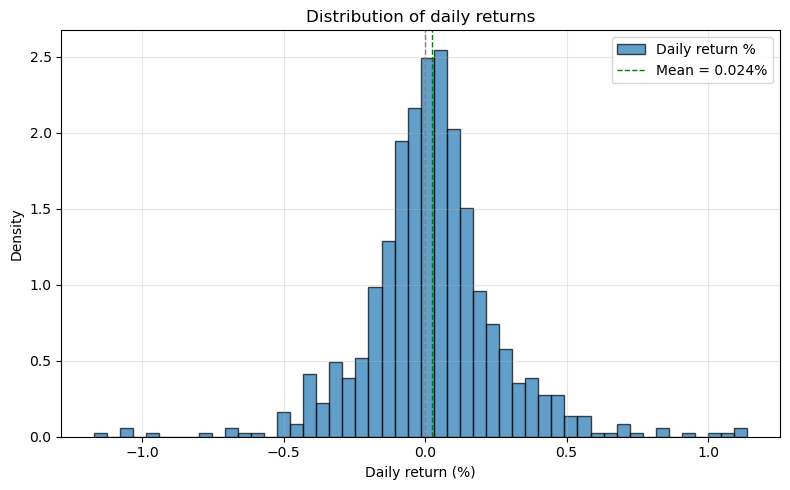

Saved: C:\Users\sarda\Desktop\cba2\data\clean\backtest\charts\daily_returns_distribution.png


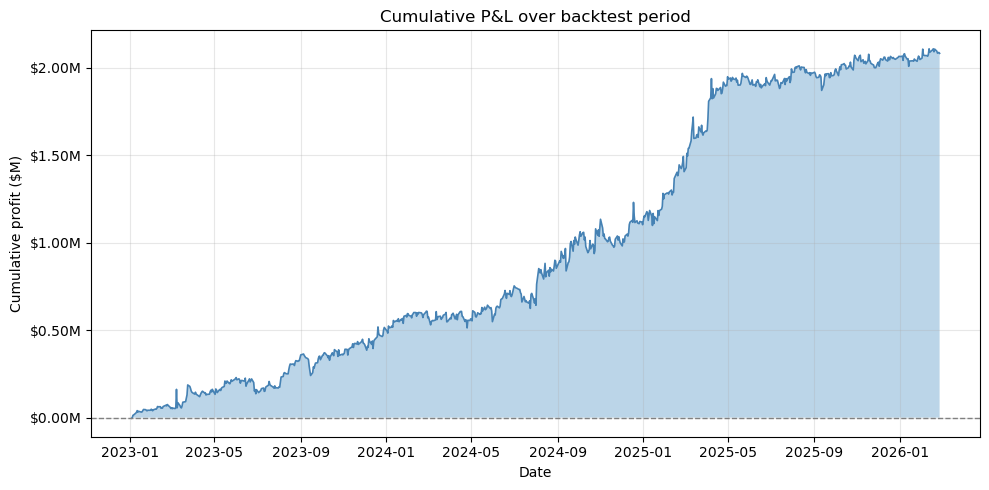

Saved: C:\Users\sarda\Desktop\cba2\data\clean\backtest\charts\cumulative_profits.png


In [16]:
# =====================================================================
# BACKTEST VISUALIZATION — Daily returns distribution & Cumulative profits
# Saves charts to output/charts/
# =====================================================================
# Run cell 0 first (and optionally run the backtest). Uses nav_df from memory
# if available, otherwise loads from data/clean/backtest/portfolio_nav.csv.

import matplotlib.pyplot as plt
import numpy as np

CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

# Get NAV data: use in-memory nav_df if available, else load from CSV
if "nav_df" in dir() and nav_df is not None and not nav_df.empty:
    df = nav_df.copy()
    start_capital = STARTING_CAPITAL if "STARTING_CAPITAL" in dir() else df["nav"].iloc[0]
else:
    import pandas as pd
    path = os.path.join(OUTPUT_DIR, "portfolio_nav.csv")
    df = pd.read_csv(path, parse_dates=["date"])
    start_capital = df["nav"].iloc[0]

df["daily_return"] = df["nav"].pct_change().fillna(0)
df["cumulative_profit"] = df["nav"] - start_capital

# ── 1. Distribution of daily returns ─────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
daily_ret_pct = df["daily_return"] * 100
ax1.hist(daily_ret_pct, bins=50, edgecolor="black", alpha=0.7, density=True, label="Daily return %")
ax1.axvline(0, color="gray", linestyle="--", linewidth=1)
ax1.axvline(daily_ret_pct.mean(), color="green", linestyle="--", linewidth=1, label=f"Mean = {daily_ret_pct.mean():.3f}%")
ax1.set_xlabel("Daily return (%)")
ax1.set_ylabel("Density")
ax1.set_title("Distribution of daily returns")
ax1.legend()
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
path1 = os.path.join(CHARTS_DIR, "daily_returns_distribution.png")
fig1.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path1}")

# ── 2. Cumulative profits vs date ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
profit_m = df["cumulative_profit"] / 1e6
ax2.plot(df["date"], profit_m, color="steelblue", linewidth=1.2)
ax2.fill_between(df["date"], profit_m, alpha=0.3)
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
ax2.set_xlabel("Date")
ax2.set_ylabel("Cumulative profit ($M)")
ax2.set_title("Cumulative P&L over backtest period")
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:.2f}M"))
fig2.tight_layout()
path2 = os.path.join(CHARTS_DIR, "cumulative_profits.png")
fig2.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path2}")

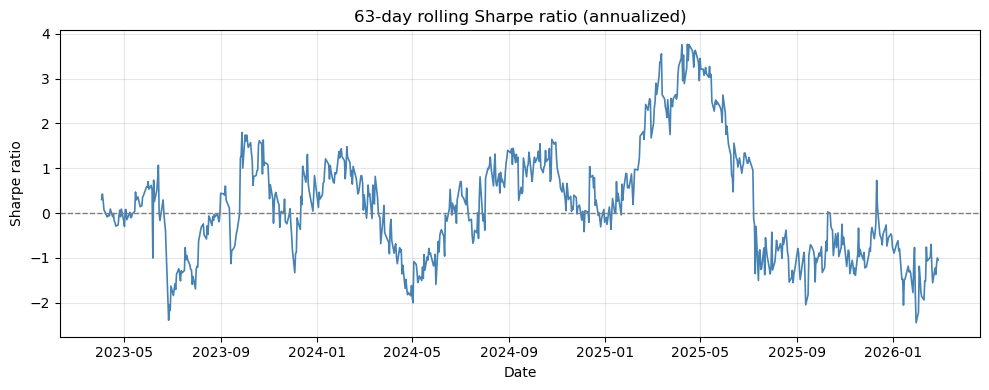

Saved: C:\Users\sarda\Desktop\cba2\data\clean\backtest\charts\rolling_sharpe_63d.png


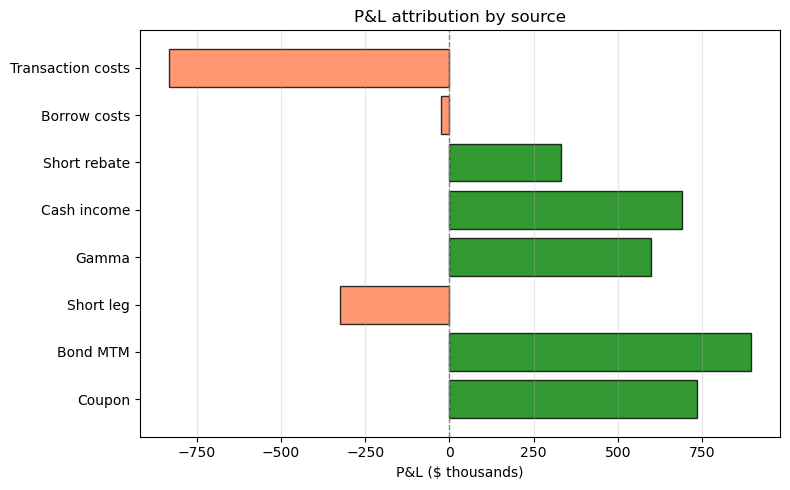

Saved: C:\Users\sarda\Desktop\cba2\data\clean\backtest\charts\pnl_by_source.png


In [17]:
# =====================================================================
# Rolling Sharpe (63-day) & P&L by source — saved to output/charts/
# =====================================================================
# Run cell 0 first. Loads portfolio_nav.csv and performance.csv.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

# Load NAV for rolling Sharpe
nav_path = os.path.join(OUTPUT_DIR, "portfolio_nav.csv")
df_nav = pd.read_csv(nav_path, parse_dates=["date"])
df_nav["daily_return"] = df_nav["nav"].pct_change().fillna(0)

# Load performance for P&L by source and avg rf
perf_path = os.path.join(OUTPUT_DIR, "performance.csv")
perf = pd.read_csv(perf_path).iloc[0]

ROLLING_DAYS = 63
rf_annual = perf.get("avg_rf_rate_pct", 4.5) / 100
rf_daily = rf_annual / 252

# ── 1. 63-day rolling Sharpe ─────────────────────────────────────────────
r = df_nav["daily_return"].values
excess = r - rf_daily
roll_mean = pd.Series(excess).rolling(ROLLING_DAYS, min_periods=ROLLING_DAYS).mean()
roll_std  = pd.Series(excess).rolling(ROLLING_DAYS, min_periods=ROLLING_DAYS).std()
rolling_sharpe = (roll_mean / roll_std * np.sqrt(252)).values

fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df_nav["date"], rolling_sharpe, color="steelblue", linewidth=1.2)
ax1.axhline(0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("Date")
ax1.set_ylabel("Sharpe ratio")
ax1.set_title(f"{ROLLING_DAYS}-day rolling Sharpe ratio (annualized)")
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
path1 = os.path.join(CHARTS_DIR, "rolling_sharpe_63d.png")
fig1.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path1}")

# ── 2. P&L by source (bar chart) ─────────────────────────────────────────
sources = [
    ("Coupon", perf["pnl_coupon"]),
    ("Bond MTM", perf["pnl_bond_mtm"]),
    ("Short leg", perf["pnl_short"]),
    ("Gamma", perf["pnl_gamma"]),
    ("Cash income", perf["pnl_cash"]),
    ("Short rebate", perf["pnl_rebate"]),
    ("Borrow costs", -perf["costs_borrow"]),
    ("Transaction costs", -perf["costs_tc"]),
]
labels = [s[0] for s in sources]
values = [s[1] for s in sources]
colors = ["green" if v >= 0 else "coral" for v in values]

fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.barh(labels, np.array(values) / 1e3, color=colors, edgecolor="black", alpha=0.8)
ax2.axvline(0, color="gray", linestyle="--", linewidth=1)
ax2.set_xlabel("P&L ($ thousands)")
ax2.set_title("P&L attribution by source")
ax2.grid(True, alpha=0.3, axis="x")
fig2.tight_layout()
path2 = os.path.join(CHARTS_DIR, "pnl_by_source.png")
fig2.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path2}")

In [2]:
# save as build_6040_and_sp500_returns_fixed.py
# pip install yfinance pandas

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# ------------- CONFIG -------------
START = "2023-01-01"
END   = "2026-02-27"   # inclusive intention (yfinance generally returns up to this date)
SP500_IDX = "^GSPC"     # S&P 500 index
EQUITY = "SPY"          # equity ETF
BOND   = "AGG"          # bond ETF

OUT_SP500 = "sp500_daily_returns_20230101_20260227.csv"
OUT_6040  = "6040_daily_returns_20230101_20260227.csv"
OUT_BOTH  = "sp500_and_6040_daily_returns_20230101_20260227.csv"
# ----------------------------------

tickers = [SP500_IDX, EQUITY, BOND]

def download_prices_robust(tickers, start, end):
    """
    Download adjusted prices robustly from yfinance.
    Handles MultiIndex (fields × tickers) and single-level (tickers) outputs.
    Falls back to per-ticker download if needed.
    Returns DataFrame with columns = tickers and index = Date, containing adjusted prices.
    """
    # First try a bulk download with auto_adjust=False so 'Adj Close' often appears
    try:
        df_all = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=False)
    except Exception as e:
        raise RuntimeError("yfinance bulk download failed: " + str(e))

    # If empty, try per-ticker downloads
    if df_all.empty:
        print("Bulk download returned empty dataframe; falling back to single-ticker downloads.")
        return _download_each(tickers, start, end)

    # If df_all is MultiIndex (like columns=('Adj Close', 'SPY') or ('SPY','Adj Close') ), try to extract
    if isinstance(df_all.columns, pd.MultiIndex):
        # common layout: top-level fields ('Open','High','Low','Close','Adj Close'), second-level tickers
        # try 'Adj Close' first, then 'Close'
        if 'Adj Close' in df_all.columns.get_level_values(0):
            df_prices = df_all['Adj Close'].copy()
        elif 'Close' in df_all.columns.get_level_values(0):
            df_prices = df_all['Close'].copy()
        else:
            # Some versions invert levels: tickers first, fields second -> try to xs on level name
            # Try to locate the level which contains 'Adj Close' or 'Close'
            lvl0 = list(df_all.columns.levels[0])
            lvl1 = list(df_all.columns.levels[1])
            found = False
            if 'Adj Close' in lvl1:
                df_prices = df_all.xs('Adj Close', axis=1, level=1, drop_level=True).copy()
                found = True
            elif 'Close' in lvl1:
                df_prices = df_all.xs('Close', axis=1, level=1, drop_level=True).copy()
                found = True
            if not found:
                # final fallback: try to flatten and pick numeric columns
                flat = df_all.copy()
                flat.columns = ['{}__{}'.format(a,b) for a,b in flat.columns]
                # try to pick any column that contains 'Adj' or 'Close' for each ticker
                pieces = {}
                for t in tickers:
                    cand = [c for c in flat.columns if (t in c or c.endswith("__"+t) or c.startswith(t+"__")) and ('Adj' in c or 'Close' in c)]
                    if cand:
                        pieces[t] = flat[cand[0]]
                if len(pieces) == len(tickers):
                    df_prices = pd.DataFrame(pieces, index=flat.index)
                else:
                    print("Could not automatically find 'Adj Close' or 'Close' in the multiindexed download. Falling back to per-ticker downloads.")
                    return _download_each(tickers, start, end)
    else:
        # single-level columns: yfinance returned already auto_adjusted or only tickers/Close values
        # If columns are tickers, just subset them
        # Some outputs might have 'Adj Close' as a column name (if only 1 ticker was passed earlier)
        cols = list(df_all.columns)
        # If the columns are the tickers we requested (common when auto_adjust=True), use them
        if set(tickers).issubset(set(cols)):
            df_prices = df_all[tickers].copy()
        else:
            # maybe it's a single ticker and column names are ('Adj Close',)
            if 'Adj Close' in cols:
                # this is the case when single ticker was downloaded -> but we asked for multiple, unlikely
                df_prices = df_all['Adj Close'].to_frame()
            elif 'Close' in cols:
                df_prices = df_all['Close'].to_frame()
            else:
                # unknown layout -> fallback to single ticker downloads
                print("Unknown single-level layout; falling back to per-ticker downloads.")
                return _download_each(tickers, start, end)

    # Ensure columns are exactly the tickers and in requested order
    # sometimes ticker symbols in the download may be upper/lower or contain suffixes; try to reindex
    missing = [t for t in tickers if t not in df_prices.columns]
    if missing:
        print(f"Missing tickers in extracted prices: {missing}. Falling back to per-ticker downloads for missing tickers.")
        # download missing individually and join
        df_missing = _download_each(missing, start, end)
        # reindex df_prices to include missing columns
        df_prices = pd.concat([df_prices, df_missing], axis=1)
    # finally keep only requested tickers (and in order)
    df_prices = df_prices.reindex(columns=tickers)
    return df_prices

def _download_each(tickers, start, end):
    """Download adjusted close for each ticker separately (guarantees a simple DataFrame of Adj Close)."""
    pieces = []
    for t in tickers:
        try:
            df_t = yf.download(t, start=start, end=end, progress=False, auto_adjust=False)
            if df_t.empty:
                raise RuntimeError(f"yfinance returned empty data for {t}")
            # prefer 'Adj Close' then 'Close'
            if 'Adj Close' in df_t.columns:
                s = df_t['Adj Close'].rename(t)
            elif 'Close' in df_t.columns:
                s = df_t['Close'].rename(t)
            else:
                raise RuntimeError(f"Cannot find price column for {t} in per-ticker download")
            pieces.append(s)
        except Exception as e:
            raise RuntimeError(f"Failed to download {t}: {e}")
    df = pd.concat(pieces, axis=1)
    return df

# ---------------------------------
# Run download and build returns
# ---------------------------------
df_prices = download_prices_robust(tickers, START, END)

# Drop dates where any ticker missing (safest for coherent portfolio returns)
df_prices = df_prices.dropna(axis=0, how='any')

if df_prices.empty:
    raise RuntimeError("After dropping NaNs there is no overlapping price data for the requested tickers/dates.")

# compute simple daily returns
df_ret = df_prices.pct_change().dropna(how='any')

# SP500 returns series
sp500_returns = df_ret[SP500_IDX].rename("SP500_return")
sp500_returns.to_csv(OUT_SP500, header=True, index_label="date")

# 60/40 portfolio (daily rebalanced = weighted sum of daily returns)
portfolio_returns = (0.6 * df_ret[EQUITY] + 0.4 * df_ret[BOND]).rename("6040_return")
portfolio_returns.to_csv(OUT_6040, header=True, index_label="date")

# combined file (optional)
combined = pd.concat([sp500_returns, portfolio_returns], axis=1)
combined.to_csv(OUT_BOTH, index_label="date")

print("Saved files:", OUT_SP500, OUT_6040, OUT_BOTH)
print("Rows in output:", len(combined), "from", combined.index.min().date(), "to", combined.index.max().date())

Saved files: sp500_daily_returns_20230101_20260227.csv 6040_daily_returns_20230101_20260227.csv sp500_and_6040_daily_returns_20230101_20260227.csv
Rows in output: 789 from 2023-01-04 to 2026-02-26


In [13]:
import os
import getpass
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# 0. Local path setup (independent of earlier cells)
# -------------------------------------------------------------------
USER = getpass.getuser()
if USER == "sarda":
    BASE_DIR = r"C:\Users\sarda\Desktop\cba2"
elif USER == "jinay":
    BASE_DIR = r"C:\Users\jinay\Desktop\cba2"
else:
    BASE_DIR = r"C:\Users\sarda\Desktop\cba2"  # fallback

OUTPUT_DIR   = os.path.join(BASE_DIR, "data", "clean", "backtest")
DISCOUNT_PATH = os.path.join(BASE_DIR, "data", "clean", "final_discount_rates_daily.csv")

# -------------------------------------------------------------------
# 1. Load strategy NAV and compute daily returns
# -------------------------------------------------------------------
nav_path = os.path.join(OUTPUT_DIR, "portfolio_nav.csv")
if not os.path.exists(nav_path):
    raise FileNotFoundError(f"portfolio_nav.csv not found at {nav_path}. Run the backtest first.")

nav_df = pd.read_csv(nav_path, parse_dates=["date"])
nav_df = nav_df.sort_values("date").reset_index(drop=True)

nav_df["strategy_ret"] = nav_df["nav"].pct_change()
nav_df = nav_df.dropna(subset=["strategy_ret"])

# -------------------------------------------------------------------
# 2. Load index daily returns (S&P 500 and 60/40) from CSV
#    File: code/sp500_and_6040_daily_returns_20230101_20260227.csv
#    Columns (by position): col 0 = date, col 1 = SP500_return, col 2 = 6040_return
# -------------------------------------------------------------------
index_path = os.path.join(
    BASE_DIR,
    "code",
    "sp500_and_6040_daily_returns_20230101_20260227.csv"
)
if not os.path.exists(index_path):
    raise FileNotFoundError(f"Index CSV not found at {index_path}.")

idx_raw = pd.read_csv(index_path)
date_col, sp500_col, pf6040_col = idx_raw.columns[0], idx_raw.columns[1], idx_raw.columns[2]

idx_df = pd.DataFrame({
    "date": pd.to_datetime(idx_raw[date_col], errors="coerce", infer_datetime_format=True),
    "sp500_ret": pd.to_numeric(idx_raw[sp500_col], errors="coerce"),
    "pf6040_ret": pd.to_numeric(idx_raw[pf6040_col], errors="coerce"),
}).dropna(subset=["date", "sp500_ret", "pf6040_ret"])
idx_df = idx_df.sort_values("date").reset_index(drop=True)

# -------------------------------------------------------------------
# 3. Load risk-free rate (1y) and build daily rf
# -------------------------------------------------------------------
rf_df = pd.read_csv(DISCOUNT_PATH)
rf_df["Date"] = pd.to_datetime(rf_df["Date"])
rf_df = rf_df.sort_values("Date")

# Use merge_asof: for each trading date, nearest rf date
rf_df = rf_df[["Date", "risk_free_1y"]].rename(columns={"Date": "date"})
rf_df = rf_df.sort_values("date").reset_index(drop=True)

# -------------------------------------------------------------------
# 4. Align all series on date and build excess returns
# -------------------------------------------------------------------
merged = (
    nav_df[["date", "strategy_ret"]]
    .merge(idx_df, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

merged = pd.merge_asof(
    merged.sort_values("date"),
    rf_df.sort_values("date"),
    on="date",
    direction="nearest",
)

# risk_free_1y is in %, convert to decimal, then to daily rate
merged["rf_annual"] = merged["risk_free_1y"]  # already a decimal, e.g. 0.045 for 4.5%
merged["rf_daily"]  = (1.0 + merged["rf_annual"]) ** (1.0 / 252.0) - 1.0

# Excess returns
merged["strategy_excess"] = merged["strategy_ret"] - merged["rf_daily"]
merged["sp500_excess"]    = merged["sp500_ret"]    - merged["rf_daily"]
merged["pf6040_excess"]   = merged["pf6040_ret"]   - merged["rf_daily"]

# Clean NaNs
merged = merged.dropna(subset=["strategy_excess", "sp500_excess", "pf6040_excess"])

print(f"Aligned rows for CAPM alpha/beta: {len(merged)}")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")

# -------------------------------------------------------------------
# 5. Correlations (still on raw daily returns, as before)
# -------------------------------------------------------------------
corr_sp   = merged["strategy_ret"].corr(merged["sp500_ret"])
corr_6040 = merged["strategy_ret"].corr(merged["pf6040_ret"])

print("\n=== Correlations (daily returns, raw) ===")
print(f"Corr(strategy, S&P 500):  {corr_sp: .4f}")
print(f"Corr(strategy, 60/40):    {corr_6040: .4f}")

# -------------------------------------------------------------------
# 6. CAPM-style regression helpers on EXCESS returns
# -------------------------------------------------------------------
def single_factor_capm(y_excess, x_excess):
    """
    y_excess: Series of (strategy - rf) daily returns
    x_excess: Series of (factor - rf) daily returns
    Returns: alpha_daily, alpha_annual, beta
    """
    x_mean = x_excess.mean()
    y_mean = y_excess.mean()
    cov_yx = np.cov(y_excess, x_excess, ddof=0)[0, 1]
    var_x  = np.var(x_excess, ddof=0)
    beta   = cov_yx / var_x if var_x != 0 else np.nan
    alpha_daily  = y_mean - beta * x_mean
    alpha_annual = (1 + alpha_daily) ** 252 - 1
    return alpha_daily, alpha_annual, beta

def two_factor_capm(y_excess, X_excess):
    """
    y_excess: Series (strategy - rf)
    X_excess: DataFrame with factor excess returns columns, e.g. ['sp500_excess','pf6040_excess']
    Returns: alpha_daily, alpha_annual, betas (dict)
    """
    X_mat = np.column_stack([np.ones(len(X_excess)), X_excess.values])
    y_vec = y_excess.values
    coef, *_ = np.linalg.lstsq(X_mat, y_vec, rcond=None)
    alpha_daily  = coef[0]
    alpha_annual = (1 + alpha_daily) ** 252 - 1
    betas = dict(zip(X_excess.columns, coef[1:]))
    return alpha_daily, alpha_annual, betas

# -------------------------------------------------------------------
# 7. CAPM: vs S&P 500 (excess returns)
# -------------------------------------------------------------------
print("\n=== CAPM vs S&P 500 (excess returns) ===")
a_d, a_a, beta_sp = single_factor_capm(
    merged["strategy_excess"],
    merged["sp500_excess"],
)
print(f"Alpha_excess (daily):      {a_d: .6f}")
print(f"Alpha_excess (annualized): {a_a: .4%}")
print(f"Beta_excess(SP500):        {beta_sp: .4f}")

# -------------------------------------------------------------------
# 8. CAPM: vs 60/40 (excess returns)
# -------------------------------------------------------------------
print("\n=== CAPM vs 60/40 (excess returns) ===")
a_d, a_a, beta_6040 = single_factor_capm(
    merged["strategy_excess"],
    merged["pf6040_excess"],
)
print(f"Alpha_excess (daily):      {a_d: .6f}")
print(f"Alpha_excess (annualized): {a_a: .4%}")
print(f"Beta_excess(60/40):        {beta_6040: .4f}")

# -------------------------------------------------------------------
# 9. Two-factor CAPM: vs S&P 500 + 60/40 (excess returns)
# -------------------------------------------------------------------
print("\n=== CAPM vs S&P 500 + 60/40 (two-factor, excess returns) ===")
X_two_excess = merged[["sp500_excess", "pf6040_excess"]]
a_d, a_a, betas_two = two_factor_capm(
    merged["strategy_excess"],
    X_two_excess,
)
print(f"Alpha_excess (daily):      {a_d: .6f}")
print(f"Alpha_excess (annualized): {a_a: .4%}")
for name, beta_val in betas_two.items():
    print(f"Beta_excess({name}):        {beta_val: .4f}")

Aligned rows for CAPM alpha/beta: 789
Date range: 2023-01-04 to 2026-02-26

=== Correlations (daily returns, raw) ===
Corr(strategy, S&P 500):  -0.2708
Corr(strategy, 60/40):    -0.2594

=== CAPM vs S&P 500 (excess returns) ===
Alpha_excess (daily):       0.000112
Alpha_excess (annualized):  2.8548%
Beta_excess(SP500):        -0.0688

=== CAPM vs 60/40 (excess returns) ===
Alpha_excess (daily):       0.000111
Alpha_excess (annualized):  2.8295%
Beta_excess(60/40):        -0.1015

=== CAPM vs S&P 500 + 60/40 (two-factor, excess returns) ===
Alpha_excess (daily):       0.000111
Alpha_excess (annualized):  2.8449%
Beta_excess(sp500_excess):        -0.0803
Beta_excess(pf6040_excess):         0.0183


C:\Users\sarda\AppData\Local\Temp\ipykernel_21844\323672284.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  "date": pd.to_datetime(idx_raw[date_col], errors="coerce", infer_datetime_format=True),
